In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw_data/dynamic_supply_chain_logistics_dataset.csv")

In [3]:
print("First 5 Rows of Dataset:")
print(df.head())

First 5 Rows of Dataset:
          timestamp  vehicle_gps_latitude  vehicle_gps_longitude  \
0  01-01-2021 00:00             40.375568             -77.014318   
1  01-01-2021 01:00             33.507818            -117.036902   
2  01-01-2021 02:00             30.020640             -75.269224   
3  01-01-2021 03:00             36.649223             -70.190529   
4  01-01-2021 04:00             30.001279             -70.012195   

   fuel_consumption_rate  eta_variation_hours  traffic_congestion_level  \
0               5.136512             4.998009                  5.927586   
1               5.101512             0.984929                  1.591992   
2               5.090803             4.972665                  8.787765   
3               8.219558             3.095064                  0.045257   
4               5.000075             3.216077                  8.004851   

   warehouse_inventory_level  loading_unloading_time  \
0                 985.716862                4.951392   
1  

In [4]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(32065, 26)


In [5]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude',
       'fuel_consumption_rate', 'eta_variation_hours',
       'traffic_congestion_level', 'warehouse_inventory_level',
       'loading_unloading_time', 'handling_equipment_availability',
       'order_fulfillment_status', 'weather_condition_severity',
       'port_congestion_level', 'shipping_costs', 'supplier_reliability_score',
       'lead_time_days', 'historical_demand', 'iot_temperature',
       'cargo_condition_status', 'route_risk_level', 'customs_clearance_time',
       'driver_behavior_score', 'fatigue_monitoring_score',
       'disruption_likelihood_score', 'delay_probability',
       'risk_classification', 'delivery_time_deviation'],
      dtype='object')


In [6]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 

In [8]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
       vehicle_gps_latitude  vehicle_gps_longitude  fuel_consumption_rate  \
count          32065.000000           32065.000000           32065.000000   
mean              38.023589             -90.116648               8.011735   
std                6.917909              17.369244               4.264960   
min               30.000000            -119.999998               5.000000   
25%               31.280550            -106.253913               5.019984   
50%               36.413820             -86.293414               5.636036   
75%               44.453655             -73.079367               9.669944   
max               50.000000             -70.000000              19.999875   

       eta_variation_hours  traffic_congestion_level  \
count         32065.000000              3.206500e+04   
mean              2.893068              4.991493e+00   
std               2.274044              3.532048e+00   
min              -1.999993              1.090000e-09   
25%  

In [9]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
timestamp                          0
vehicle_gps_latitude               0
vehicle_gps_longitude              0
fuel_consumption_rate              0
eta_variation_hours                0
traffic_congestion_level           0
warehouse_inventory_level          0
loading_unloading_time             0
handling_equipment_availability    0
order_fulfillment_status           0
weather_condition_severity         0
port_congestion_level              0
shipping_costs                     0
supplier_reliability_score         0
lead_time_days                     0
historical_demand                  0
iot_temperature                    0
cargo_condition_status             0
route_risk_level                   0
customs_clearance_time             0
driver_behavior_score              0
fatigue_monitoring_score           0
disruption_likelihood_score        0
delay_probability                  0
risk_classification                0
delivery_time_deviation            0
dtype: int64


In [10]:
print("\nDuplicate Rows :", df.duplicated().sum())


Duplicate Rows : 0


In [16]:
# Convert Timestamp Column
df['timestamp'] = pd.to_datetime(df['timestamp'],dayfirst=True)

df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour

print(df[['timestamp','year','month','day','hour']].head())


            timestamp  year  month  day  hour
0 2021-01-01 00:00:00  2021      1    1     0
1 2021-01-01 01:00:00  2021      1    1     1
2 2021-01-01 02:00:00  2021      1    1     2
3 2021-01-01 03:00:00  2021      1    1     3
4 2021-01-01 04:00:00  2021      1    1     4


In [17]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print("\nNumerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)


Numerical Columns
Index(['vehicle_gps_latitude', 'vehicle_gps_longitude',
       'fuel_consumption_rate', 'eta_variation_hours',
       'traffic_congestion_level', 'warehouse_inventory_level',
       'loading_unloading_time', 'handling_equipment_availability',
       'order_fulfillment_status', 'weather_condition_severity',
       'port_congestion_level', 'shipping_costs', 'supplier_reliability_score',
       'lead_time_days', 'historical_demand', 'iot_temperature',
       'cargo_condition_status', 'route_risk_level', 'customs_clearance_time',
       'driver_behavior_score', 'fatigue_monitoring_score',
       'disruption_likelihood_score', 'delay_probability',
       'delivery_time_deviation', 'year', 'month', 'day', 'hour'],
      dtype='object')

Categorical Columns
Index(['risk_classification'], dtype='object')


 ##  UNIVARIATE ANALYSIS

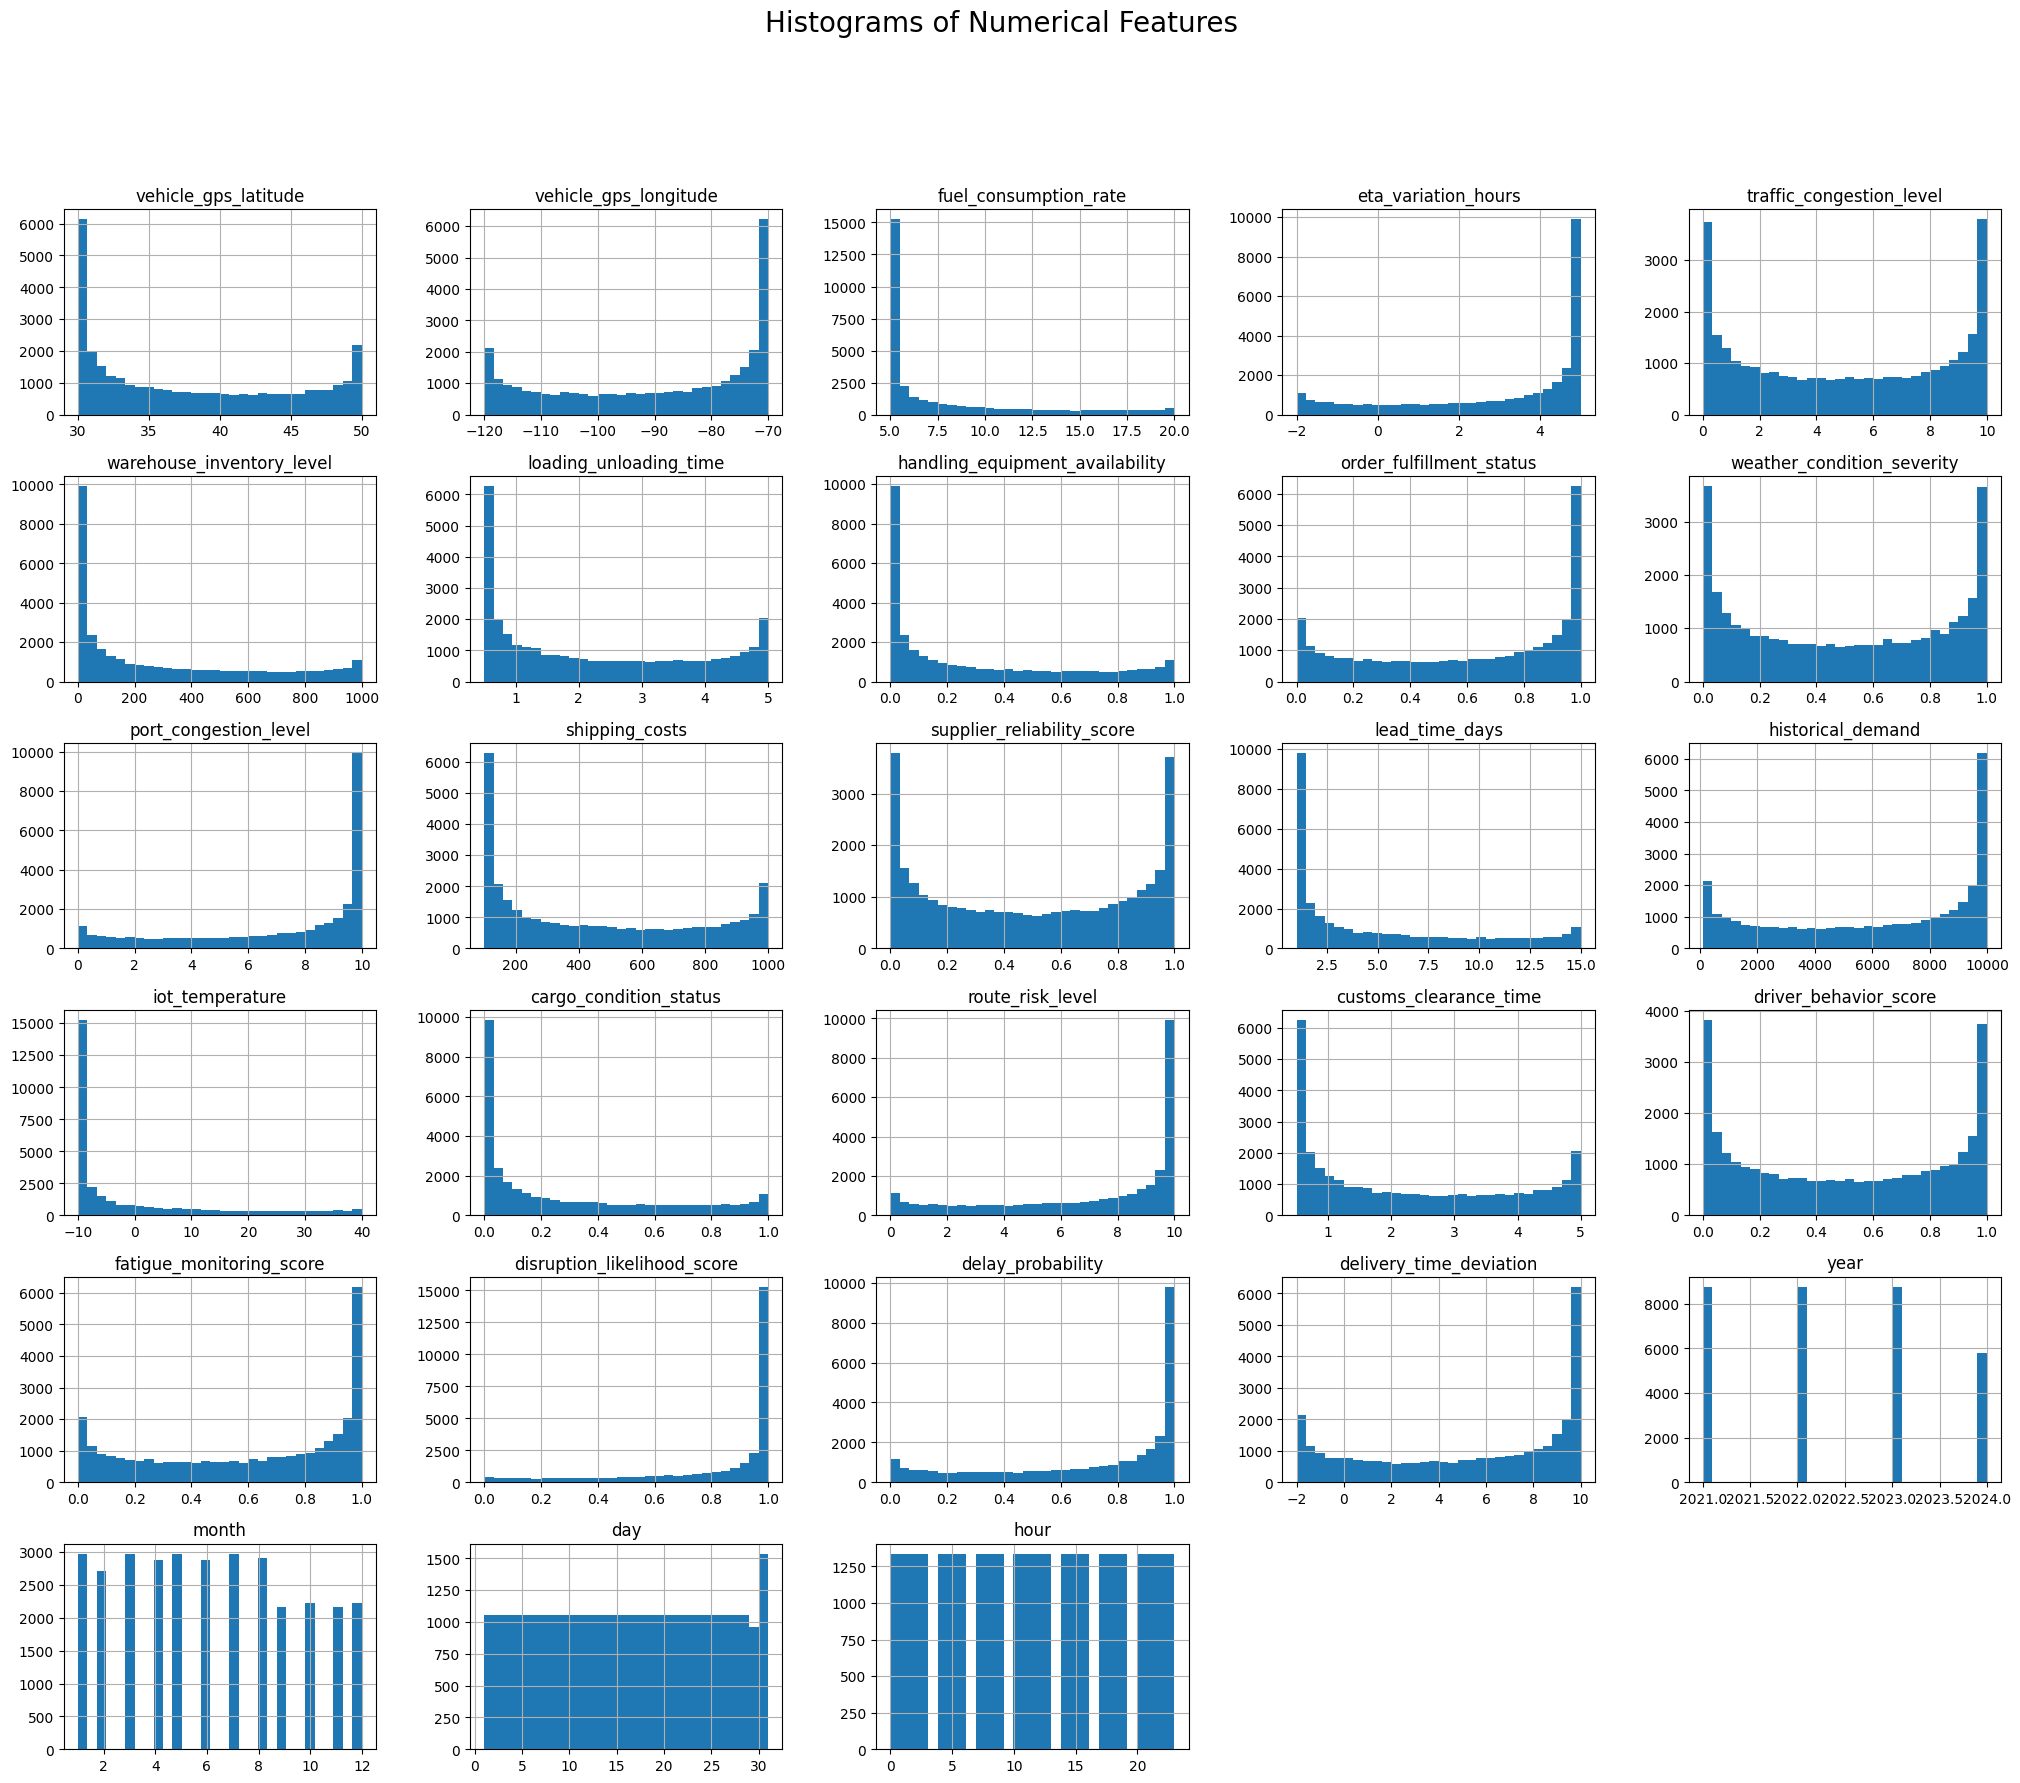

In [18]:
df[numerical_cols].hist(figsize=(25,20), bins=30)
plt.suptitle("Histograms of Numerical Features", fontsize=20)
plt.show()


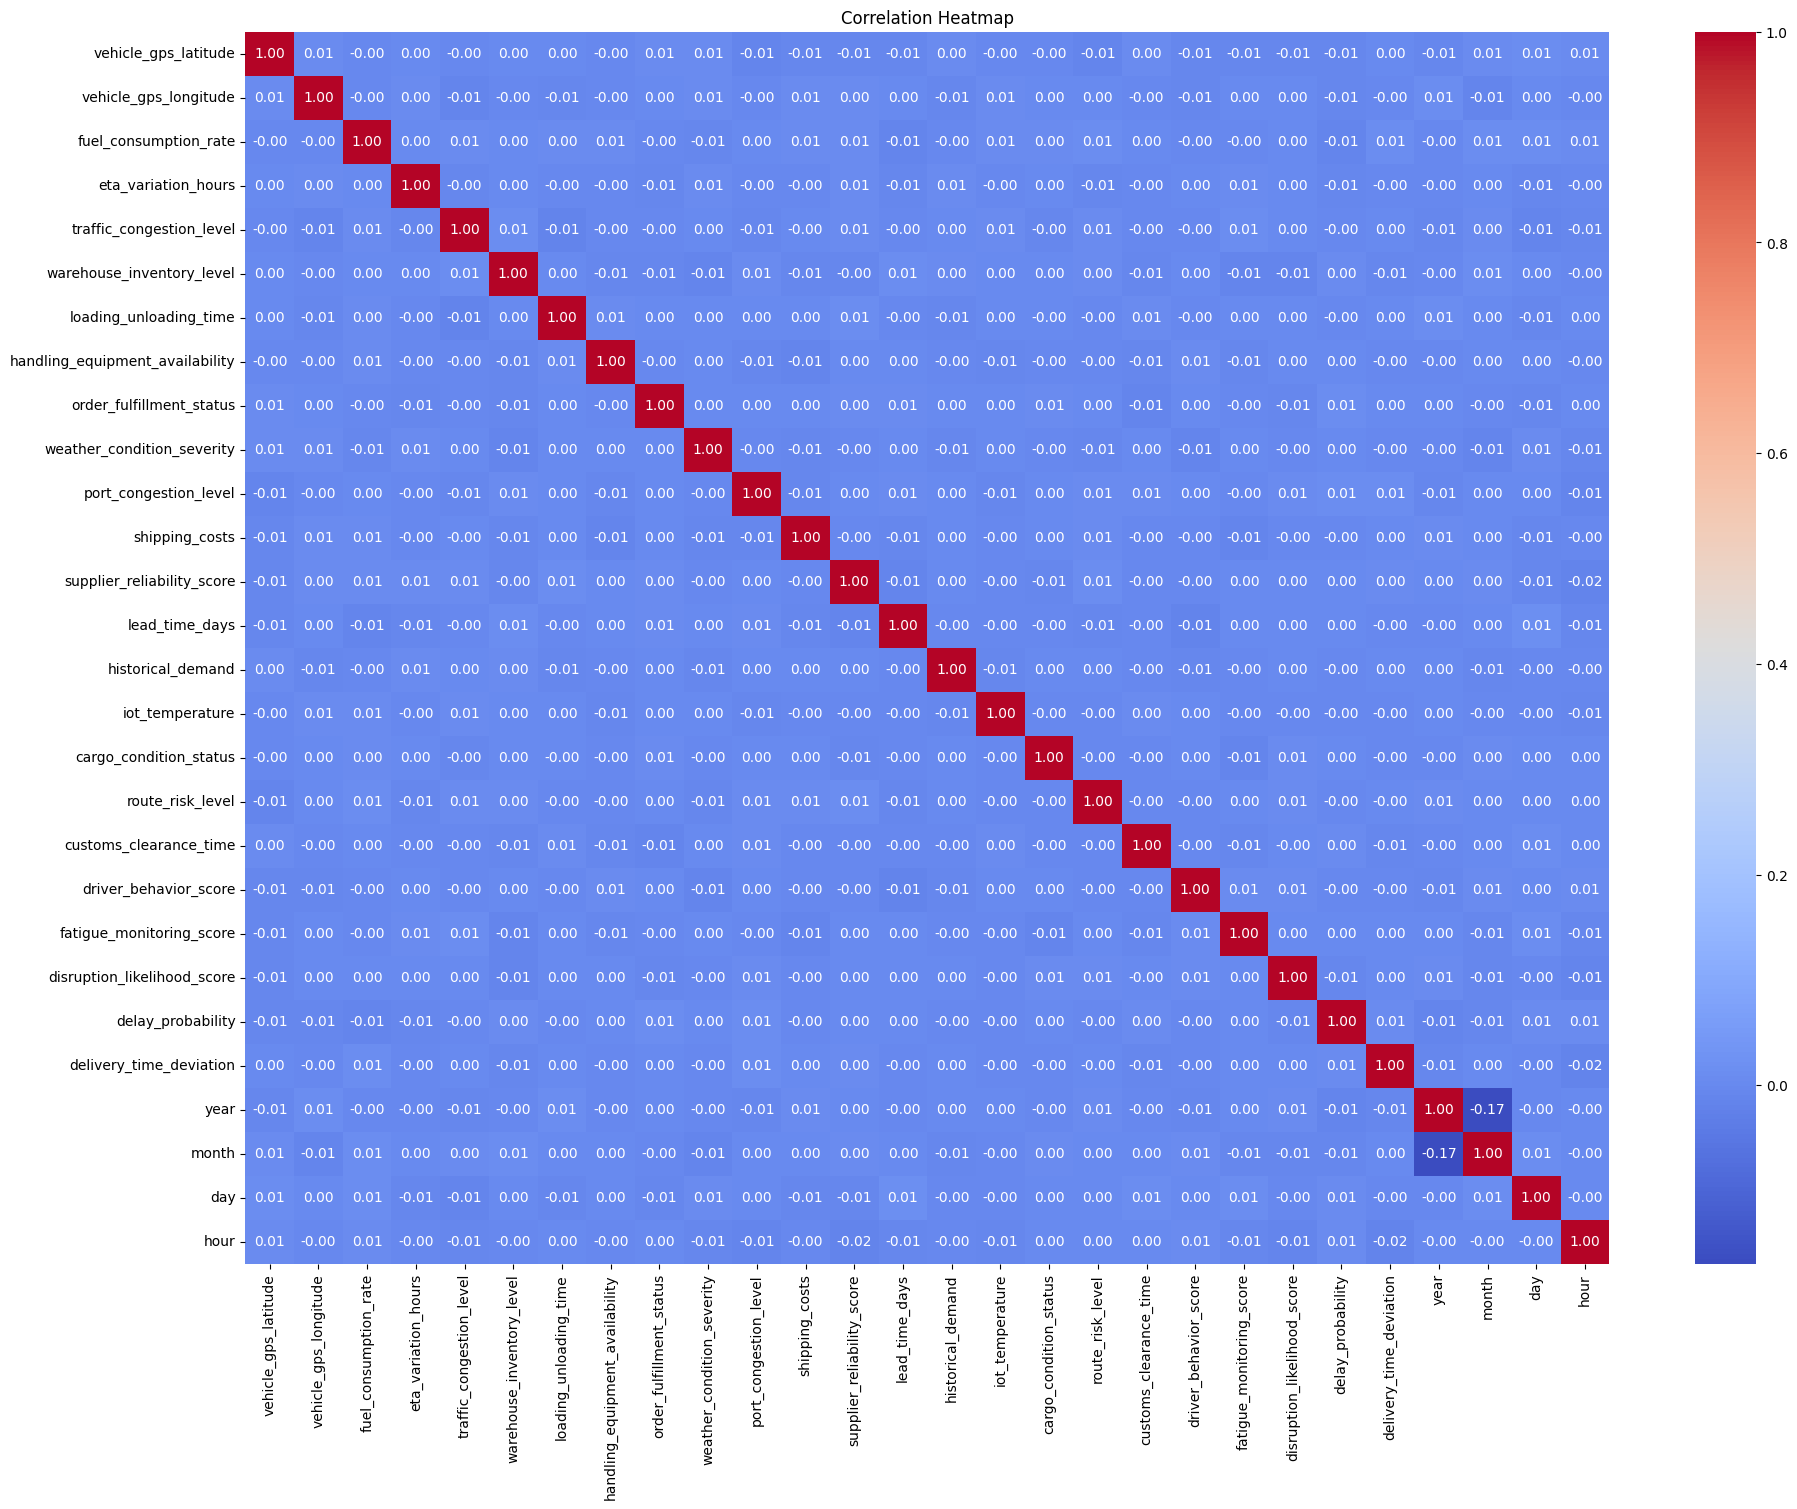

In [20]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(22,16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

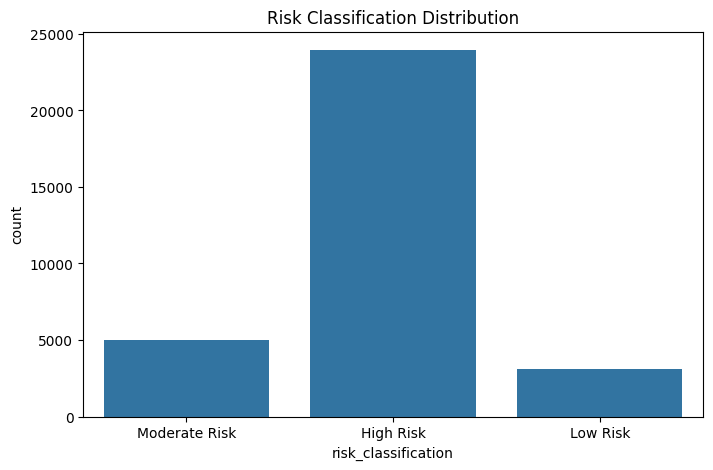

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='risk_classification', data=df)
plt.title("Risk Classification Distribution")
plt.show()

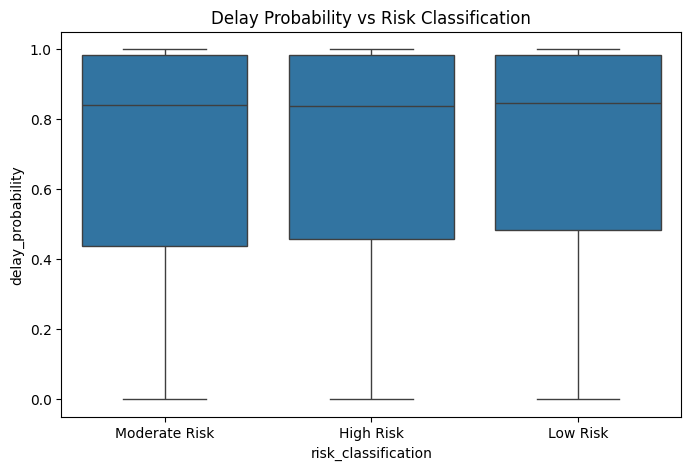

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='risk_classification', y='delay_probability', data=df)
plt.title("Delay Probability vs Risk Classification")
plt.show()

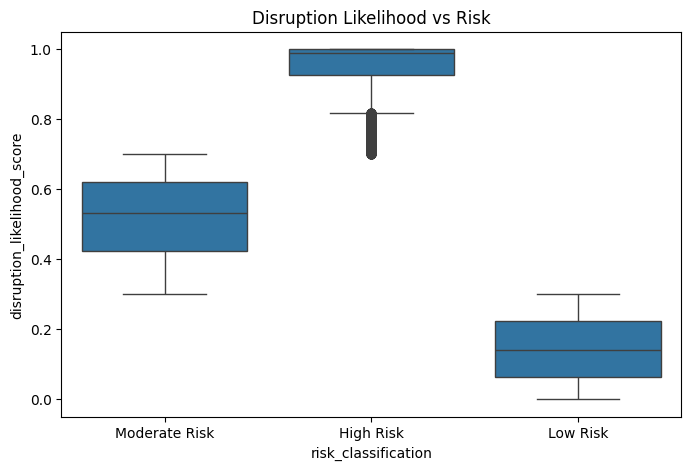

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='risk_classification',
            y='disruption_likelihood_score',
            data=df)

plt.title("Disruption Likelihood vs Risk")
plt.show()

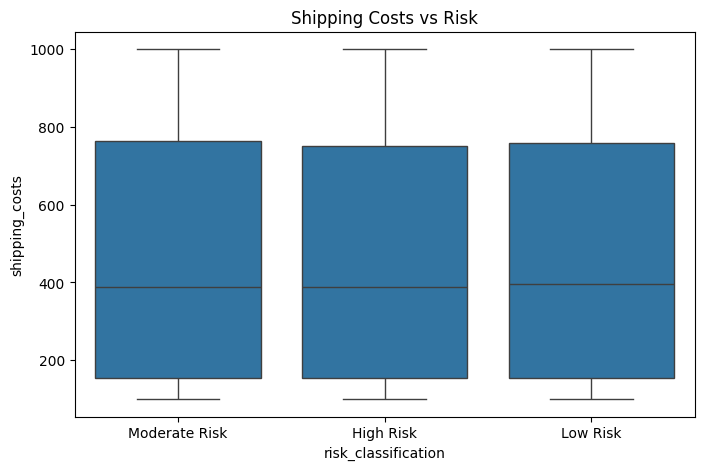

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='risk_classification',
            y='shipping_costs',
            data=df)

plt.title("Shipping Costs vs Risk")
plt.show()

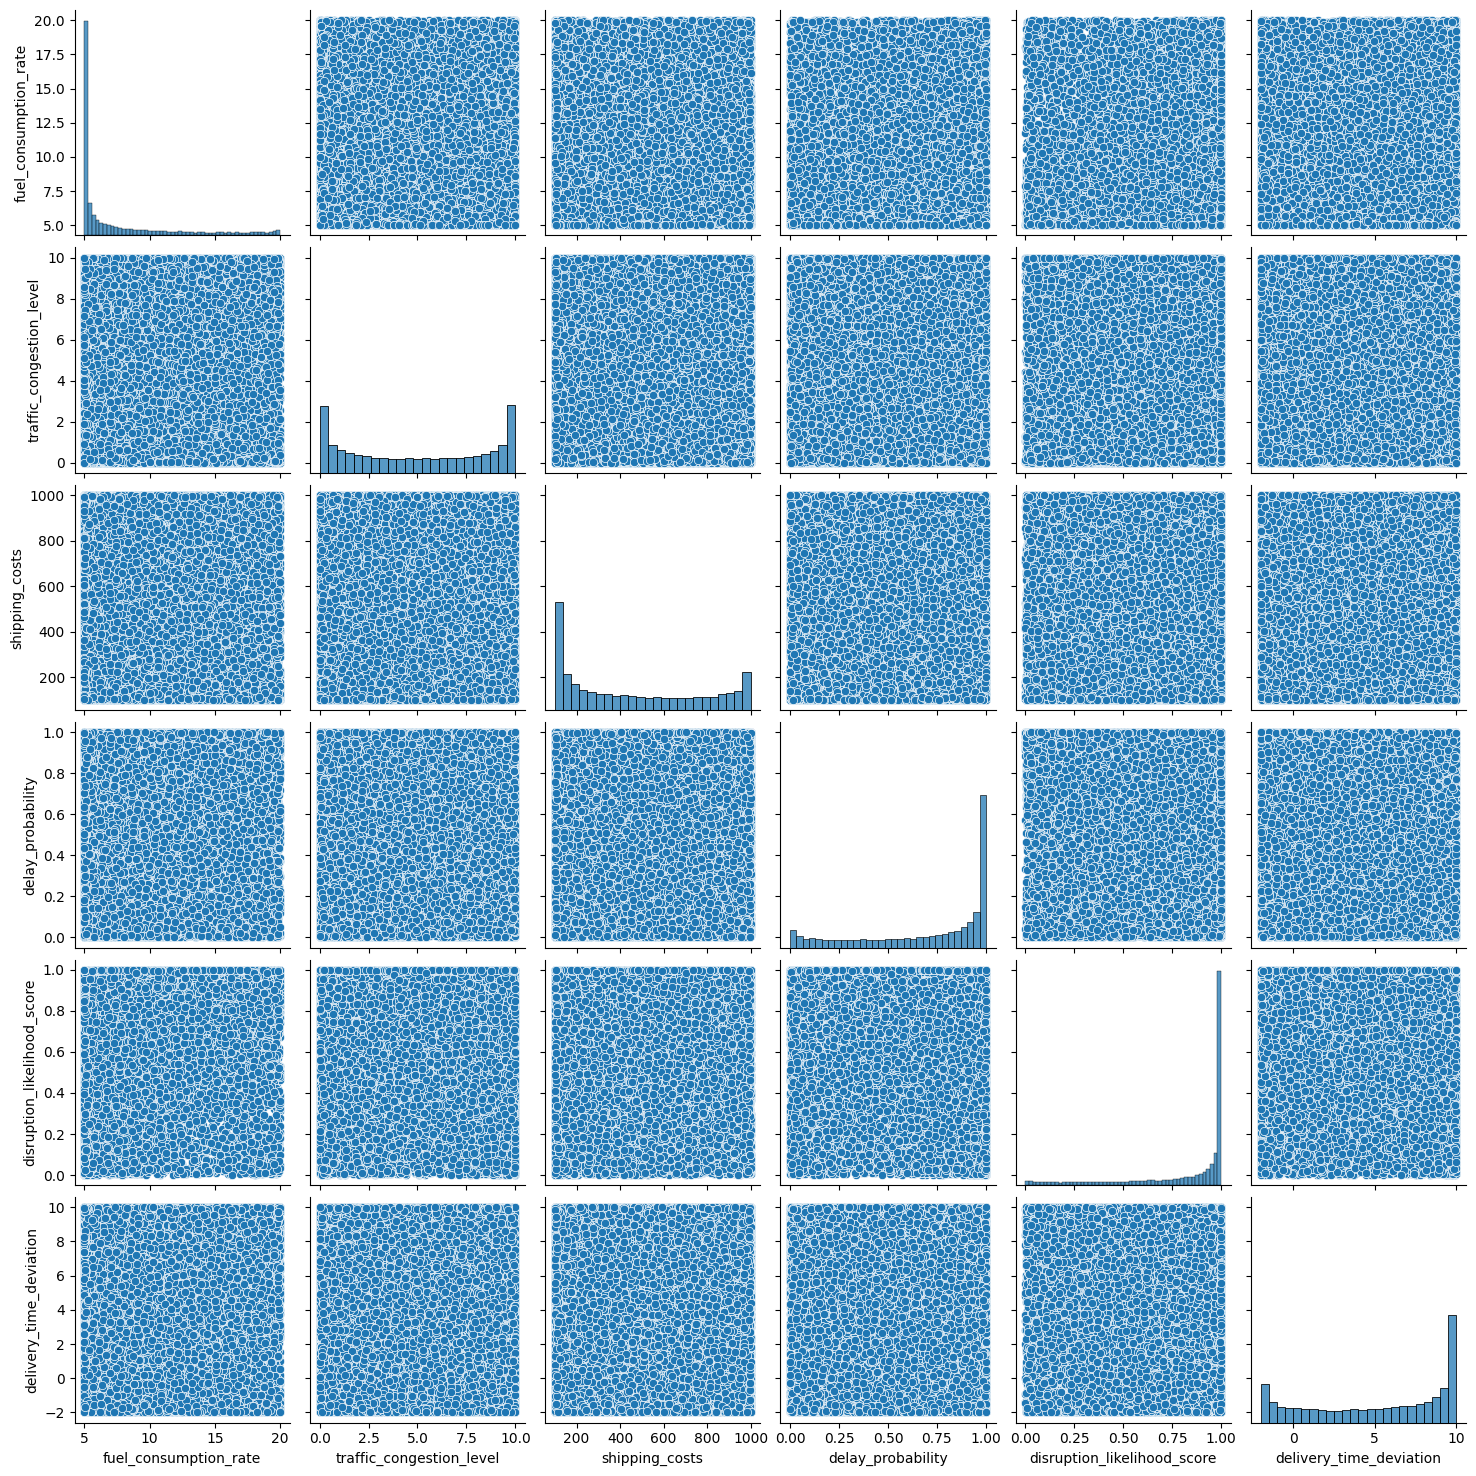

In [30]:
selected_cols = [
    'fuel_consumption_rate',
    'traffic_congestion_level',
    'shipping_costs',
    'delay_probability',
    'disruption_likelihood_score',
    'delivery_time_deviation'
]

sns.pairplot(df[selected_cols])
plt.show()


Average Delay Probability
risk_classification
High Risk        0.698595
Low Risk         0.706961
Moderate Risk    0.696487
Name: delay_probability, dtype: float64


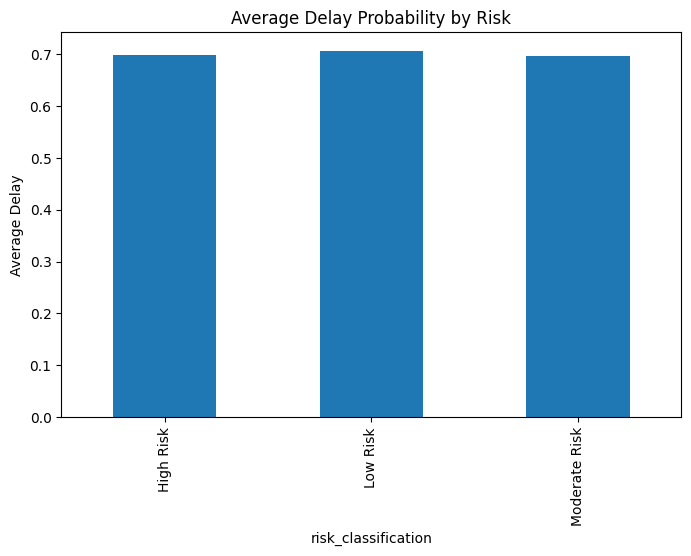

In [33]:
avg_delay = df.groupby('risk_classification')['delay_probability'].mean()

print("\nAverage Delay Probability")
print(avg_delay)

avg_delay.plot(kind='bar', figsize=(8,5))
plt.title("Average Delay Probability by Risk")
plt.ylabel("Average Delay")
plt.show()



Average Shipping Cost
risk_classification
High Risk        458.640398
Low Risk         463.119175
Moderate Risk    460.557869
Name: shipping_costs, dtype: float64


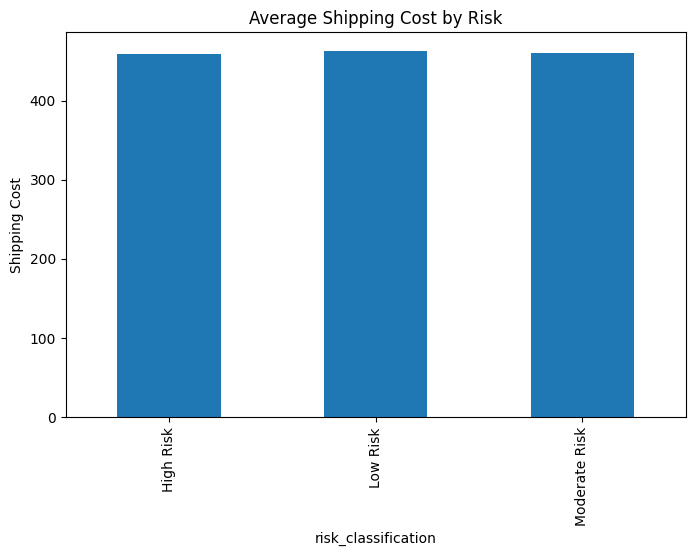

In [34]:
avg_ship = df.groupby('risk_classification')['shipping_costs'].mean()

print("\nAverage Shipping Cost")
print(avg_ship)

avg_ship.plot(kind='bar', figsize=(8,5))
plt.title("Average Shipping Cost by Risk")
plt.ylabel("Shipping Cost")
plt.show()


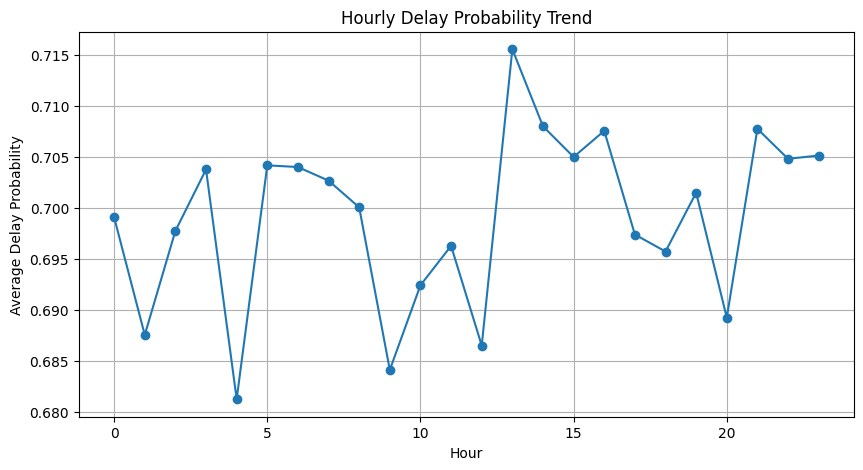

In [35]:
hourly_delay = df.groupby('hour')['delay_probability'].mean()

plt.figure(figsize=(10,5))
hourly_delay.plot(marker='o')

plt.title("Hourly Delay Probability Trend")
plt.xlabel("Hour")
plt.ylabel("Average Delay Probability")
plt.grid()
plt.show()

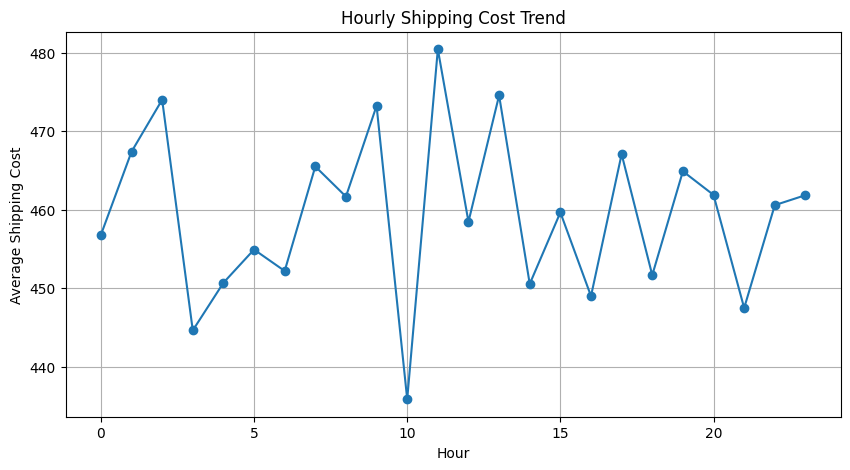

In [37]:
hourly_shipping = df.groupby('hour')['shipping_costs'].mean()

plt.figure(figsize=(10,5))
hourly_shipping.plot(marker='o')

plt.title("Hourly Shipping Cost Trend")
plt.xlabel("Hour")
plt.ylabel("Average Shipping Cost")
plt.grid()
plt.show()

In [38]:
def detect_outliers(column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    print(f"{column} : {outliers.shape[0]} outliers")

for col in numerical_cols:
    detect_outliers(col)


vehicle_gps_latitude : 0 outliers
vehicle_gps_longitude : 0 outliers
fuel_consumption_rate : 2536 outliers
eta_variation_hours : 0 outliers
traffic_congestion_level : 0 outliers
warehouse_inventory_level : 0 outliers
loading_unloading_time : 0 outliers
handling_equipment_availability : 0 outliers
order_fulfillment_status : 0 outliers
weather_condition_severity : 0 outliers
port_congestion_level : 0 outliers
shipping_costs : 0 outliers
supplier_reliability_score : 0 outliers
lead_time_days : 0 outliers
historical_demand : 0 outliers
iot_temperature : 2301 outliers
cargo_condition_status : 0 outliers
route_risk_level : 0 outliers
customs_clearance_time : 0 outliers
driver_behavior_score : 0 outliers
fatigue_monitoring_score : 0 outliers
disruption_likelihood_score : 2494 outliers
delay_probability : 0 outliers
delivery_time_deviation : 0 outliers
year : 0 outliers
month : 0 outliers
day : 0 outliers
hour : 0 outliers
